#### Возьмем несколько моделей с наилучшими результатами и рассмотрим учитываемые при построении признаки.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier, Pool

In [2]:
def matrix(model, X_test, y_test, predict_test):
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()


In [3]:
train_part1 = pd.read_parquet("../ClearData/train_part1.parquet")

x = train_part1.drop(columns="target")
y = train_part1["target"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y)  
lst = [i for i in X_train.columns]
train_pool = Pool(X_train, y_train, feature_names=lst)
test_pool = Pool(X_test, y_test, feature_names=lst)

In [5]:
weights = {0: 1, 1: 100}
CatBoost1 = CatBoostClassifier(iterations=20, depth=5, class_weights=weights, verbose=False)

Test metrics:
Accuracy: 0.9964187626229096
Precision: 0.017243335224049916
Recall: 0.08745684695051784
F1-score: 0.02880697432009855
PR-AUC: 0.0063334227179697375

Confusion matrix


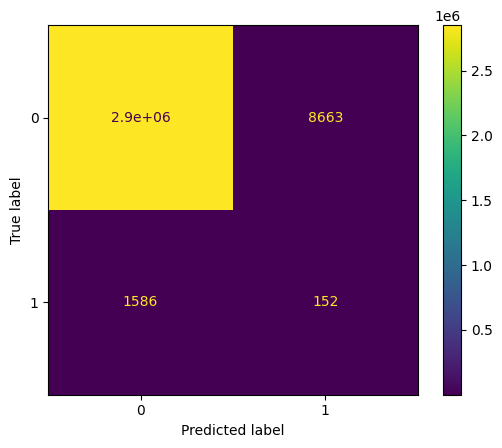

In [6]:
CatBoost1.fit(train_pool)
predict = CatBoost1.predict(test_pool)
matrix(CatBoost1, X_test, y_test, predict)

In [7]:
CatBoost1.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,mcc_code,33.404225
1,event_desc,21.496070
2,operaton_amt,17.997773
3,channel_indicator_type,6.345852
4,currency_iso_cd,4.979530
5,Hour,4.650985
6,pos_cd,4.588728
7,event_type_nm,3.107260
8,phone_voip_call_state,2.641876
9,channel_indicator_sub_type,0.408472


In [8]:
CatBoost1.get_feature_importance(type='LossFunctionChange', prettified=True, data=train_pool)

,Feature Id,Importances
0,operaton_amt,0.010945
1,mcc_code,0.005837
2,event_desc,0.003558
3,channel_indicator_type,0.002657
4,currency_iso_cd,0.002047
5,phone_voip_call_state,0.001949
6,pos_cd,0.001638
7,Hour,0.001175
8,event_type_nm,0.000994
9,channel_indicator_sub_type,0.000170


In [9]:
weights = {0: 1, 1: 500}
CatBoost2 = CatBoostClassifier(iterations=20, depth=4, class_weights=weights, verbose=False)

Test metrics:
Accuracy: 0.9613803610239494
Precision: 0.005635031719775326
Recall: 0.3567318757192175
F1-score: 0.011094806914569986
PR-AUC: 0.005415101506534307

Confusion matrix


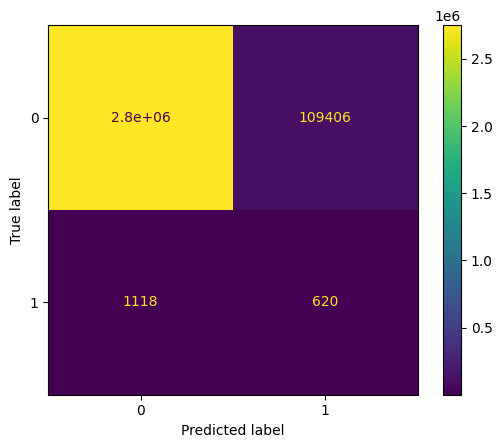

In [10]:
CatBoost2.fit(train_pool)
predict = CatBoost2.predict(test_pool)
matrix(CatBoost2, X_test, y_test, predict)

In [11]:
CatBoost2.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,mcc_code,26.723440
1,operaton_amt,23.214681
2,event_desc,15.602668
3,pos_cd,11.939449
4,channel_indicator_type,5.843491
5,phone_voip_call_state,5.332618
6,Hour,4.264819
7,currency_iso_cd,3.361357
8,event_type_nm,3.260332
9,web_rdp_connection,0.265665


In [12]:
CatBoost2.get_feature_importance(type='LossFunctionChange', prettified=True, data=train_pool)

,Feature Id,Importances
0,operaton_amt,0.033805
1,mcc_code,0.020557
2,event_desc,0.008171
3,phone_voip_call_state,0.006702
4,pos_cd,0.004866
5,channel_indicator_type,0.003820
6,Hour,0.003270
7,currency_iso_cd,0.001763
8,event_type_nm,0.001673
9,web_rdp_connection,0.000272
